In [72]:
#Librerie
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os
import matplotlib.patches as patches
from scipy.optimize import curve_fit
from scipy.signal import find_peaks, savgol_filter
from scipy import ndimage

In [73]:
percorso_cartella=r"/Users/carmelo/Desktop/Università/III ANNO/Lab di Fisica Moderna/Esperienze/Dualismo_Onda-Particella/Analisi_Dati/immagini"
immagini={}
for nome_file in os.listdir(percorso_cartella):
    if nome_file.lower().endswith((".jpeg", ".jpg", ".png")):
        percorso = os.path.join(percorso_cartella, nome_file)
        immagini[nome_file] = np.array(Image.open(percorso).convert('L'))
print(f"Caricate {len(immagini)} immagini: {list(immagini.keys())}")

Caricate 18 immagini: ['3600_c2.jpeg', '2900_c2.jpeg', '4500_v.jpeg', '3800_v.jpeg', '3400_v.jpeg', '4000_c2.jpeg', '4500_c1.jpeg', '4050_c1.jpeg', '3900_c1.jpeg', '4550_c2.jpeg', '3750_c2.jpeg', '4350_c1.jpeg', '3200_c2.jpeg', '4350_v.jpeg', '4200_c2.jpeg', '3600_c1.jpeg', '4100_v.jpeg', '3300_c2.jpeg']


(np.int64(345), np.int64(323))
189


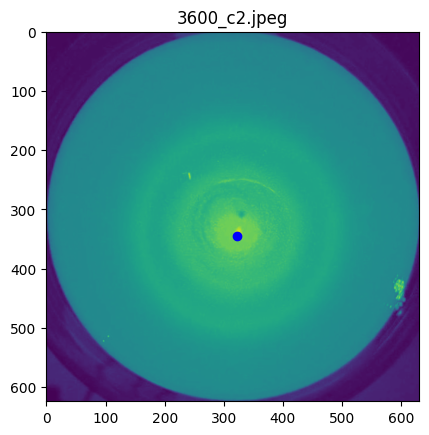

(np.int64(322), np.int64(305))
255


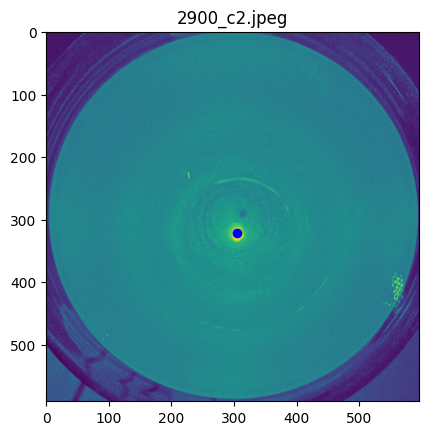

(np.int64(647), np.int64(638))
255


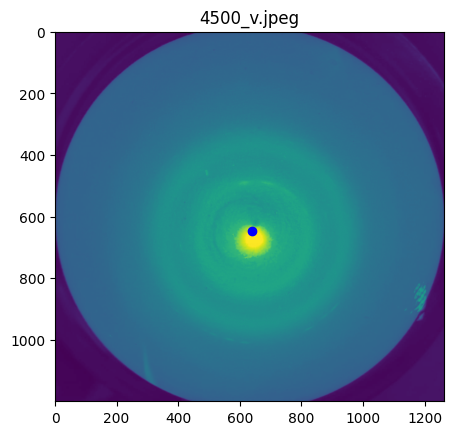

(np.int64(662), np.int64(640))
255


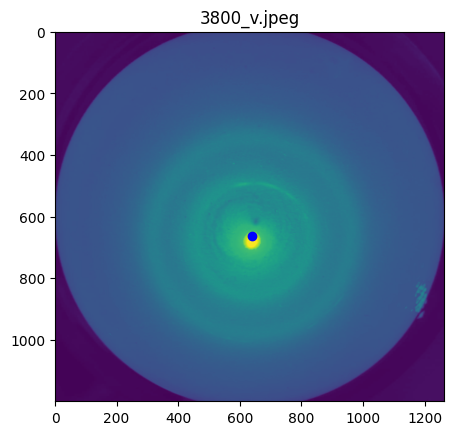

(np.int64(682), np.int64(634))
255


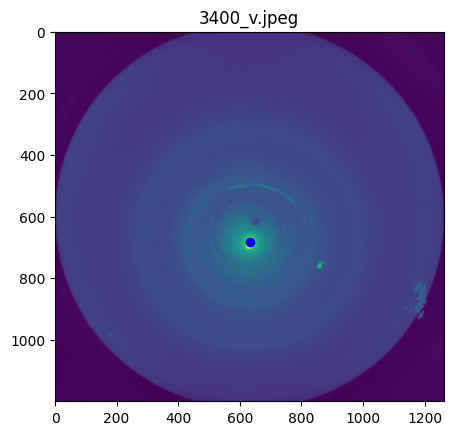

(np.int64(397), np.int64(383))
180


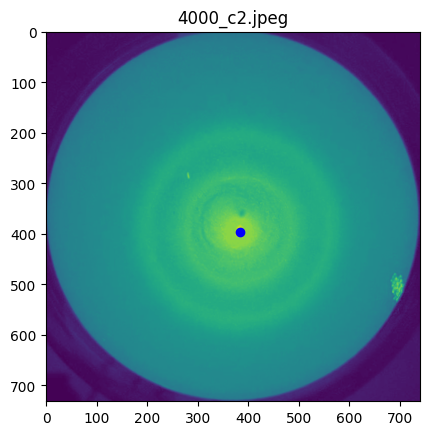

(np.int64(411), np.int64(386))
237


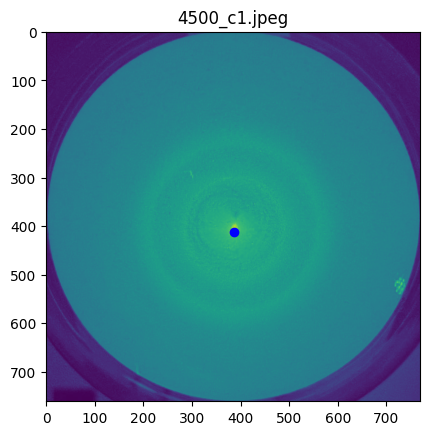

(np.int64(320), np.int64(298))
206


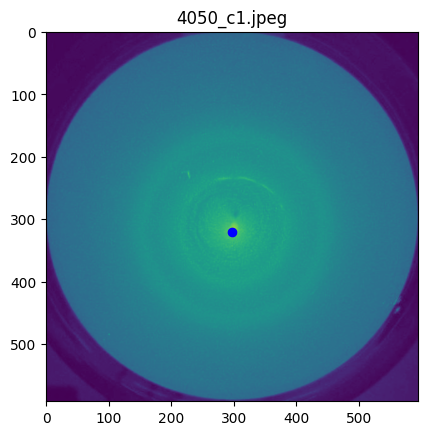

(np.int64(325), np.int64(310))
223


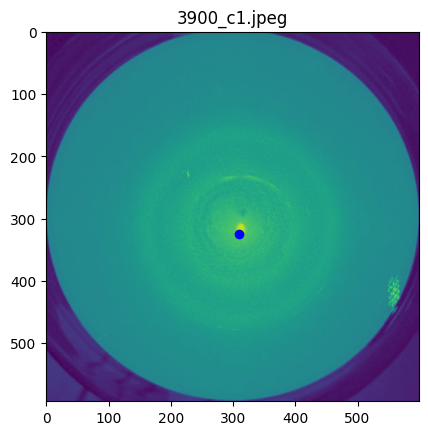

(np.int64(354), np.int64(344))
201


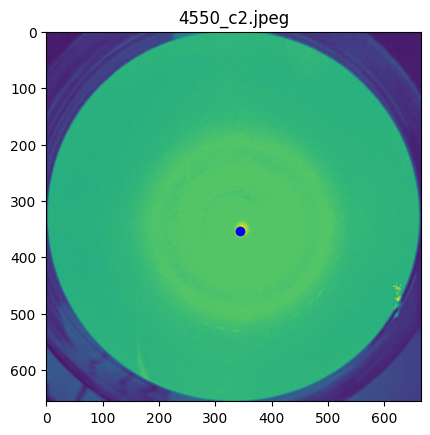

(np.int64(346), np.int64(330))
255


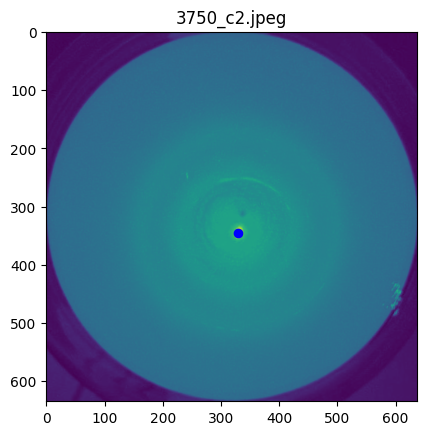

(np.int64(311), np.int64(296))
236


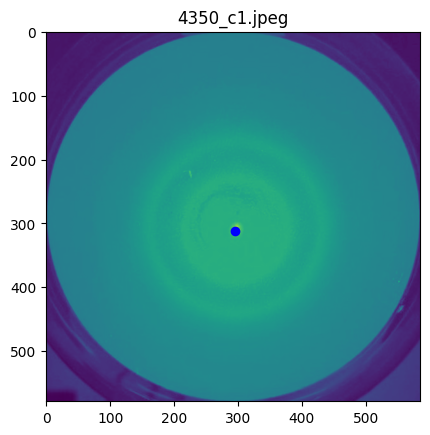

(np.int64(362), np.int64(333))
167


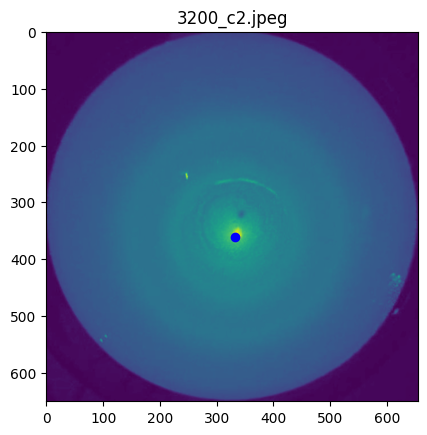

(np.int64(662), np.int64(635))
255


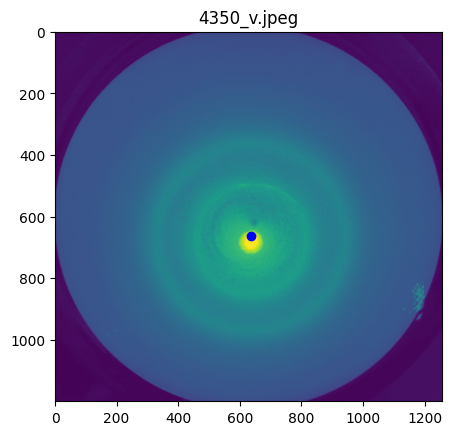

(np.int64(401), np.int64(382))
197


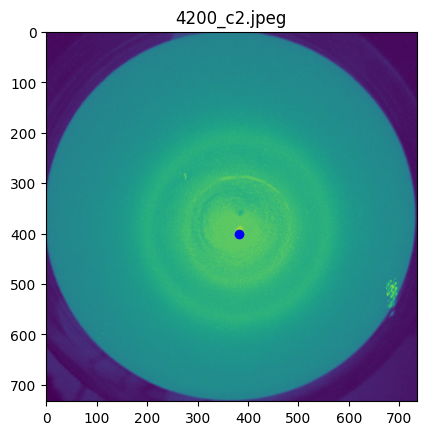

(np.int64(329), np.int64(311))
201


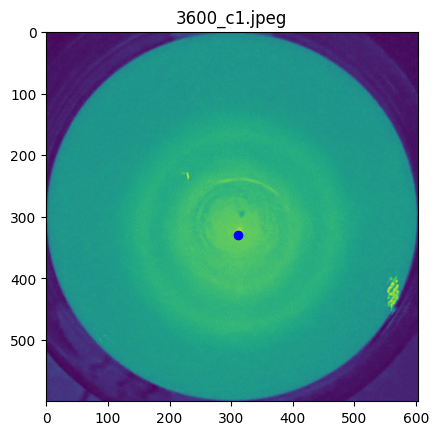

(np.int64(658), np.int64(643))
255


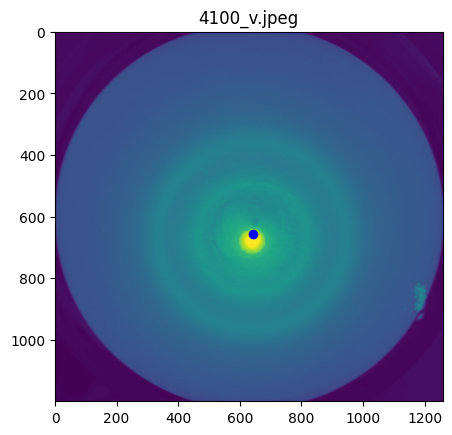

(np.int64(330), np.int64(296))
171


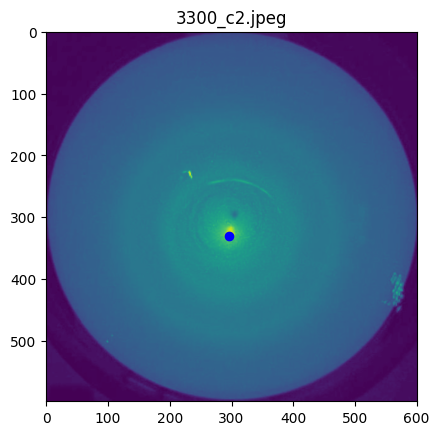

In [74]:
for nome in immagini:
    img=immagini[nome]
    coords = np.unravel_index(np.argmax(img), img.shape)
    print(coords)
    print(img[coords])
    
    plt.title(nome) 
    plt.scatter(coords[1], coords[0], c='b')
    plt.imshow(img)
    plt.show()

In [75]:
def gaussian_2d(xy, amplitude, x0, y0, sigma_x, sigma_y, offset):
    """Gaussiana 2D (appiattita per curve_fit)."""
    x, y = xy
    return (offset + amplitude * np.exp(
        -((x - x0)**2 / (2 * sigma_x**2) + (y - y0)**2 / (2 * sigma_y**2))
    )).ravel()


def gaussian_peak(r, A, r0, sigma, B):
    """Gaussiana 1D + baseline."""
    return A * np.exp(-(r - r0)**2 / (2 * sigma**2)) + B


def find_green_circle(image_gray, threshold=20, erosion_iter=3):
    """Rileva lo schermo verde e fitta un cerchio. Ritorna (cx, cy, R) in px."""
    mask = ndimage.binary_fill_holes(image_gray > threshold)
    labeled, nf = ndimage.label(mask)
    sizes = ndimage.sum(mask, labeled, range(1, nf + 1))
    screen = (labeled == int(np.argmax(sizes)) + 1)
    edges = screen.astype(int) - ndimage.binary_erosion(
        screen, iterations=erosion_iter).astype(int)
    ey, ex = np.where(edges > 0)
    A_mat = np.column_stack([2*ex, 2*ey, -np.ones(len(ex))])
    params, _, _, _ = np.linalg.lstsq(A_mat, ex**2 + ey**2, rcond=None)
    a, b, c = params
    return a, b, np.sqrt(a**2 + b**2 - c)


def find_center(image, roi_radius=30):
    """Centro sub-pixel via fit gaussiano 2D. Ritorna (col, riga, σ_col, σ_riga)."""
    coords = np.unravel_index(np.argmax(image), image.shape)
    row0, col0 = coords
    r = roi_radius
    r_min, r_max = max(0, row0-r), min(image.shape[0], row0+r)
    c_min, c_max = max(0, col0-r), min(image.shape[1], col0+r)
    roi = image[r_min:r_max, c_min:c_max].astype(float)
    ny, nx = roi.shape
    X, Y = np.meshgrid(np.arange(nx), np.arange(ny))
    p0 = [roi.max()-roi.min(), nx/2., ny/2., r/3., r/3., roi.min()]
    try:
        popt, pcov = curve_fit(gaussian_2d, (X, Y), roi.ravel(),
                               p0=p0, maxfev=10000)
        perr = np.sqrt(np.diag(pcov))
        return popt[1]+c_min, popt[2]+r_min, perr[1], perr[2]
    except RuntimeError:
        return float(col0), float(row0), np.nan, np.nan


def radial_profile(image, center):
    """Profilo radiale azimutalmente mediato. Ritorna (r, I_mean)."""
    x0, y0 = center
    Y, X = np.mgrid[0:image.shape[0], 0:image.shape[1]]
    R_int = np.sqrt((X - x0)**2 + (Y - y0)**2).astype(int)
    s = np.bincount(R_int.ravel(), weights=image.ravel().astype(float))
    n = np.bincount(R_int.ravel())
    m = n > 0
    I = np.zeros_like(s)
    I[m] = s[m] / n[m]
    return np.arange(len(I)), I


def find_half_max_radii(r_data, I_data):
    """Trova r_inner, r_outer al semi-massimo.
    
    Usa baseline indipendente per lato interno ed esterno per gestire
    picchi asimmetrici (es. su coda dello spot centrale).
    """
    idx_pk = np.argmax(I_data)
    peak_val = I_data[idx_pk]

    # Baseline lato interno: minimo tra inizio finestra e picco
    bl_inner = I_data[:idx_pk+1].min() if idx_pk > 0 else I_data[0]
    # Baseline lato esterno: minimo tra picco e fine finestra
    bl_outer = I_data[idx_pk:].min() if idx_pk < len(I_data)-1 else I_data[-1]

    # Semi-massimo per ciascun lato
    hm_inner = bl_inner + (peak_val - bl_inner) / 2.0
    hm_outer = bl_outer + (peak_val - bl_outer) / 2.0

    r_in = r_out = np.nan

    # Lato interno: cerca crossing dal basso verso half_max_inner
    for k in range(idx_pk):
        if I_data[k] <= hm_inner < I_data[k+1]:
            f = (hm_inner - I_data[k]) / (I_data[k+1] - I_data[k])
            r_in = r_data[k] + f * (r_data[k+1] - r_data[k])
            break

    # Lato esterno: cerca crossing dall'alto verso half_max_outer
    for k in range(idx_pk, len(I_data) - 1):
        if I_data[k] > hm_outer >= I_data[k+1]:
            f = (hm_outer - I_data[k]) / (I_data[k+1] - I_data[k])
            r_out = r_data[k] + f * (r_data[k+1] - r_data[k])
            break

    return r_in, r_out


def background_subtraction(ra, Ia, sR):
    # Maschera le zone dei picchi di diffrazione (es. raggio tra 20% e 60% dello schermo)
    bg_mask = (ra < 0.2 * sR) | (ra > 0.6 * sR)
    
    # Modello di decadimento dell'alone centrale
    def bg_decay(r, a, b, c):
        return a * np.exp(-b * r) + c
    
    # Fit del background
    popt_bg, _ = curve_fit(bg_decay, ra[bg_mask], Ia[bg_mask], 
                           p0=[Ia.max(), 0.1, np.median(Ia)], maxfev=10000)
    
    # Sottrazione
    Ia_baseline = bg_decay(ra, *popt_bg)
    Ia_corrected = Ia - Ia_baseline
    
    # Ia_corrected forza un background piatto a quota zero. 
    # La funzione find_half_max_radii preesistente opererà senza distorsioni asimmetriche.
    return Ia_corrected

def analyze_image(nome, array, voltage_kV, show_plots=True):
    """Pipeline completa per una singola immagine."""
    print(f'\n{"="*70}')
    print(f'  ANALISI: {nome}  —  V = {voltage_kV} kV')
    print(f'{"="*70}')

    gray = array

    # 1. Calibrazione
    scx, scy, sR = find_green_circle(gray)
    mm_px = DIAMETRO_SCHERMO_MM / (2 * sR)
    print(f'  Schermo: Ø = {2*sR:.1f} px = 100 mm  →  {mm_px:.6f} mm/px')

    # 2. Centro
    cx, cy, _, _ = find_center(gray)
    print(f'  Centro diffrazione: ({cx:.1f}, {cy:.1f}) px')

    # 3. Profilo radiale
    ra, Ia = radial_profile(gray, (cx, cy))
    Ia = background_subtraction(ra, Ia, np.max(ra))
    Is = savgol_filter(Ia, window_length=31, polyorder=3)

    # 4. Picchi
    smk = (ra >= 0.2*sR) & (ra <= 0.6*sR)
    rs, Is2 = ra[smk], Is[smk]
    pk, _ = find_peaks(Is2, prominence=0.05, width=5, distance=20, )
    print(f'  Picchi trovati: {len(pk)}')

    results = []

    for i, p in enumerate(pk):
        rp = rs[p]
        mf = (ra >= rp - 20) & (ra <= rp + 20)
        rf = ra[mf].astype(float)
        If = Ia[mf].astype(float)
        Ifs = Is[mf]
        if len(rf) < 5:
            continue

        try:
            popt, _ = curve_fit(
                gaussian_peak, rf, If,
                p0=[If.max()-If.min(), rp, 5., If.min()],
                bounds=([0, rp-20, 0.5, -np.inf],
                        [np.inf, rp+20, 30, np.inf]),
                maxfev=10000
            )
            r0_fit = popt[1]
            sig_fit = abs(popt[2])

            # Raggi interno/esterno al semi-massimo (profilo smoothed)
            r_in, r_out = find_half_max_radii(rf, Ifs)

            # Fallback: se non trovato, usa HWHM dal fit gaussiano
            hwhm = sig_fit * np.sqrt(2 * np.log(2))
            if np.isnan(r_in):
                r_in = r0_fit - hwhm
            if np.isnan(r_out):
                r_out = r0_fit + hwhm

            r_med = (r_in + r_out) / 2.0
            dr = (r_out - r_in) / 2.0

            res = {
                'ring': i + 1,
                'r_inner_px': r_in,  'r_outer_px': r_out,
                'r_medio_px': r_med, 'delta_r_px': dr,
                'r_inner_mm': r_in * mm_px, 'r_outer_mm': r_out * mm_px,
                'r_medio_mm': r_med * mm_px, 'delta_r_mm': dr * mm_px,
            }
            results.append(res)
            print(f'  Ring {i+1}: r_int={r_in:.1f}  r_ext={r_out:.1f}  →  '
                  f'r = {r_med*mm_px:.3f} ± {dr*mm_px:.3f} mm')

        except RuntimeError as e:
            print(f'  ⚠ Ring {i+1}: fit fallito — {e}')

    # Plot
    if show_plots:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        ax = axes[0]
        ax.plot(ra, Ia, 'b-', alpha=0.3, linewidth=0.8)
        ax.plot(ra, Is, 'b-', linewidth=1.5)
        for r in results:
            ax.axvline(r['r_medio_px'], color='red', linestyle='-', alpha=0.7)
            ax.axvline(r['r_inner_px'], color='red', linestyle='--', alpha=0.4)
            ax.axvline(r['r_outer_px'], color='red', linestyle='--', alpha=0.4)
        ax.set_xlim(0, sR)
        ax.set_xlabel('Raggio (px)')
        ax.set_ylabel('Intensità')
        ax.set_title(f'{voltage_kV} kV — Profilo radiale')
        ax.grid(True, alpha=0.3)

        ax = axes[1]
        ax.imshow(gray)
        ax.scatter(cx, cy, c='white', marker='+', s=200, linewidths=2)
        cols = ['cyan', 'magenta', 'yellow']
        for j, r in enumerate(results):
            c = cols[j % len(cols)]
            ax.add_patch(patches.Circle(
                (cx, cy), r['r_medio_px'], fill=False, edgecolor=c,
                linewidth=2,
                label=f'R{r["ring"]}: {r["r_medio_mm"]:.2f}±{r["delta_r_mm"]:.2f} mm'
            ))
            ax.add_patch(patches.Circle(
                (cx, cy), r['r_inner_px'], fill=False, edgecolor=c,
                linewidth=0.8, linestyle='--'
            ))
            ax.add_patch(patches.Circle(
                (cx, cy), r['r_outer_px'], fill=False, edgecolor=c,
                linewidth=0.8, linestyle='--'
            ))
        ax.set_title(f'{voltage_kV} kV — Anelli')
        ax.legend(loc='upper right', fontsize=8)
        plt.tight_layout()
        plt.show()

    return {'voltage_kV': voltage_kV, 'mm_per_px': mm_px, 'rings': results}


print('Funzioni definite ✓')

Funzioni definite ✓


In [76]:
DIAMETRO_SCHERMO_MM=100

voltaggi=[2.9,3.2,3.3,3.4,3.6,3.6,3.75,3.8,3.9,4,4.05,4.1,4.2,4.35,4.35,4.5,4.5,4.55]

In [77]:
float(nome[0:4])

3300.0


  ANALISI: 3600_c2.jpeg  —  V = 3.6 kV
  Schermo: Ø = 634.0 px = 100 mm  →  0.157723 mm/px
  Centro diffrazione: (323.7, 341.3) px
  Picchi trovati: 2
  Ring 1: r_int=84.3  r_ext=106.3  →  r = 15.034 ± 1.732 mm
  Ring 2: r_int=156.1  r_ext=180.9  →  r = 26.574 ± 1.955 mm


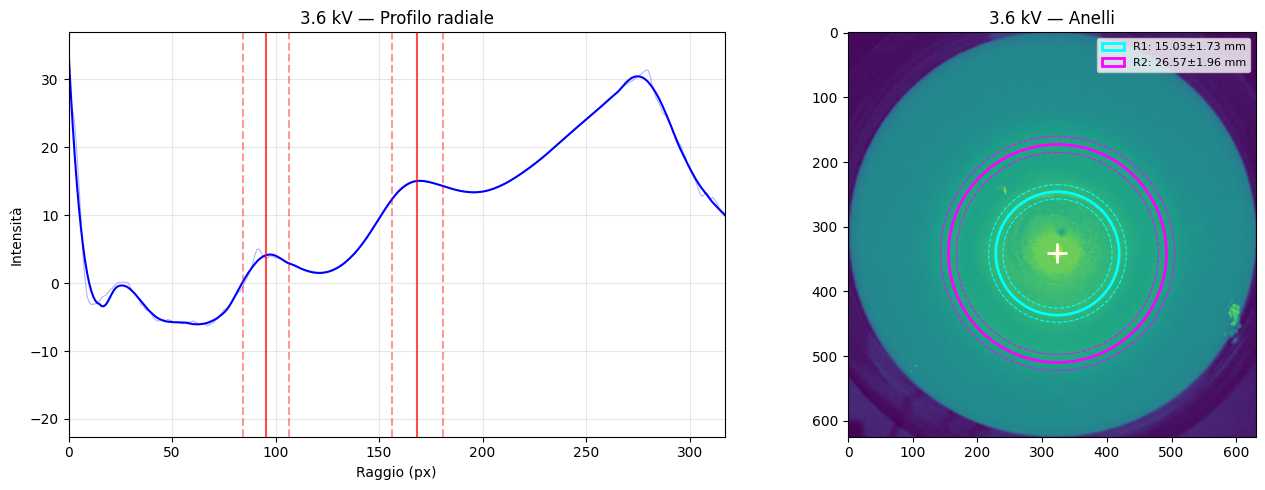


  ANALISI: 2900_c2.jpeg  —  V = 2.9 kV
  Schermo: Ø = 690.5 px = 100 mm  →  0.144824 mm/px
  Centro diffrazione: (305.0, 323.8) px
  Picchi trovati: 1
  Ring 1: r_int=92.1  r_ext=150.4  →  r = 17.562 ± 4.226 mm


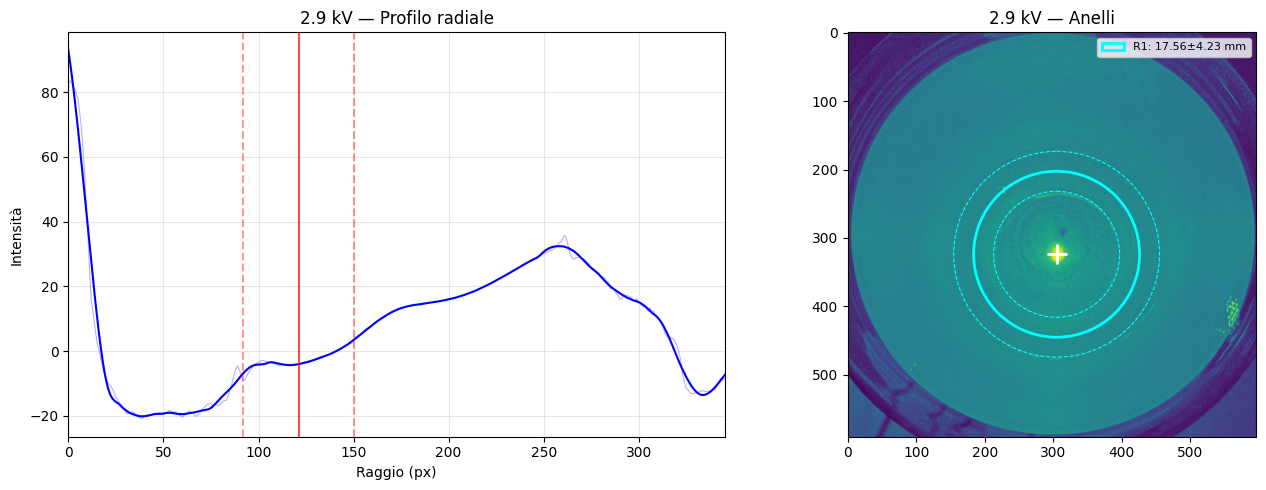


  ANALISI: 4500_v.jpeg  —  V = 4.5 kV
  Schermo: Ø = 1249.6 px = 100 mm  →  0.080025 mm/px
  Centro diffrazione: (643.6, 663.1) px
  Picchi trovati: 2
  Ring 1: r_int=167.5  r_ext=191.1  →  r = 14.346 ± 0.945 mm
  Ring 2: r_int=287.9  r_ext=315.4  →  r = 24.142 ± 1.100 mm


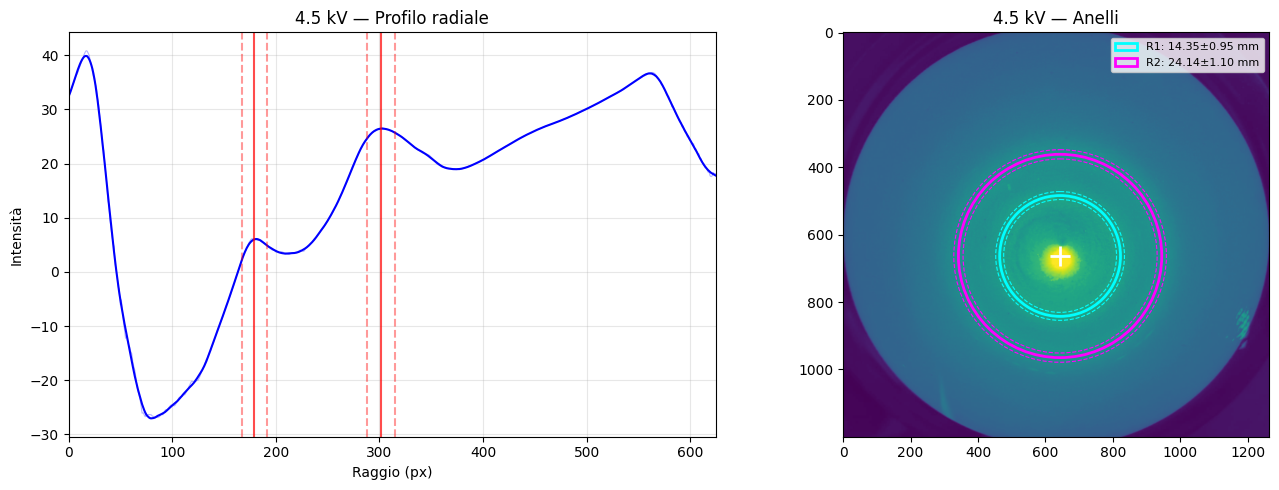


  ANALISI: 3800_v.jpeg  —  V = 3.8 kV
  Schermo: Ø = 1248.0 px = 100 mm  →  0.080130 mm/px
  Centro diffrazione: (638.3, 679.1) px
  Picchi trovati: 2
  Ring 1: r_int=177.2  r_ext=198.4  →  r = 15.047 ± 0.848 mm
  Ring 2: r_int=313.1  r_ext=340.2  →  r = 26.173 ± 1.085 mm


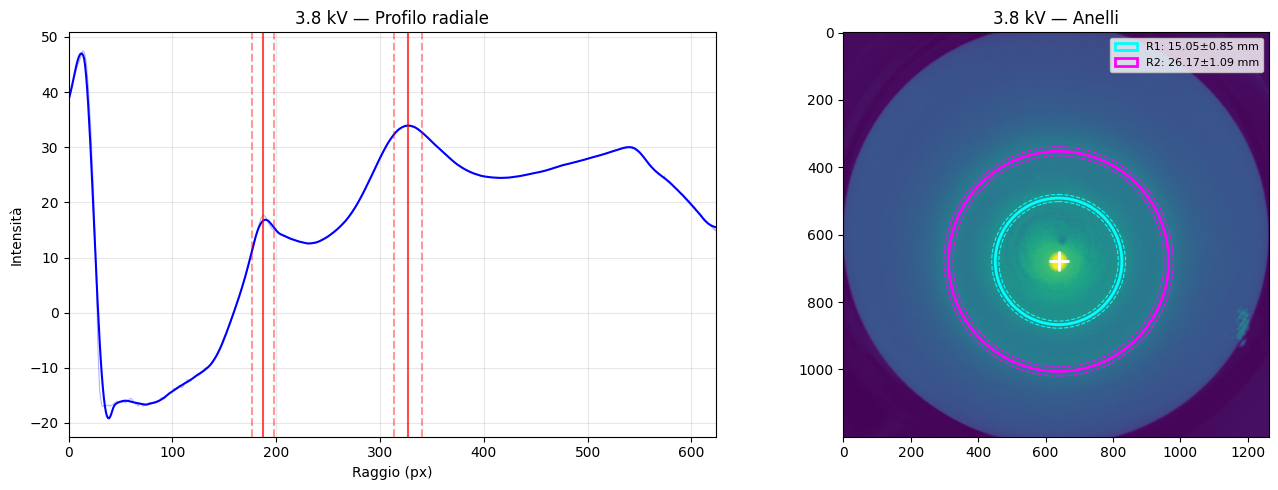


  ANALISI: 3400_v.jpeg  —  V = 3.4 kV
  Schermo: Ø = 1245.9 px = 100 mm  →  0.080262 mm/px
  Centro diffrazione: (632.4, 688.3) px
  Picchi trovati: 2
  Ring 1: r_int=208.8  r_ext=219.1  →  r = 17.173 ± 0.411 mm
  Ring 2: r_int=335.7  r_ext=363.3  →  r = 28.050 ± 1.107 mm


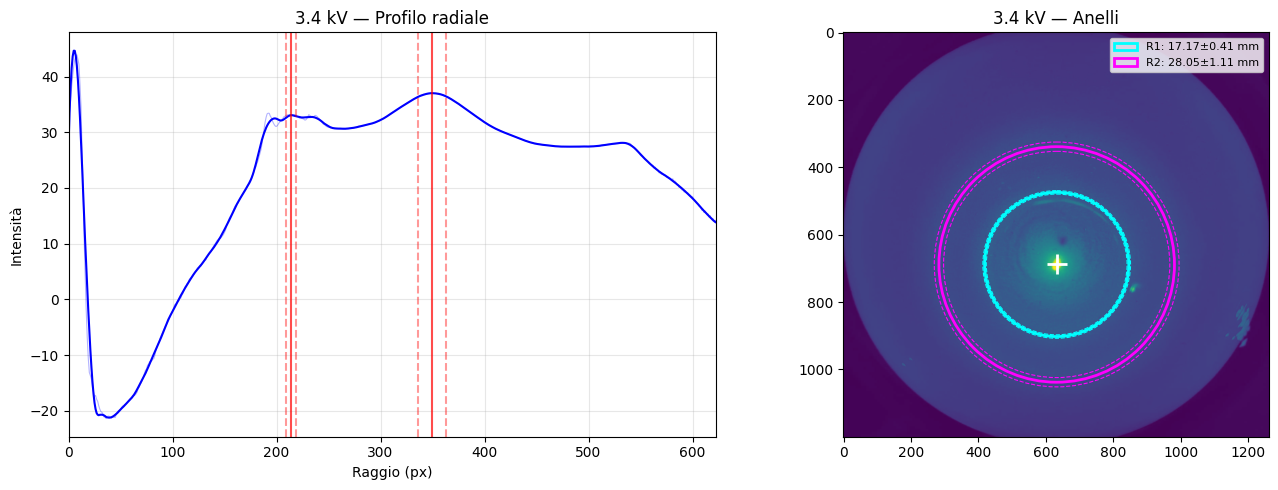


  ANALISI: 4000_c2.jpeg  —  V = 4.0 kV
  Schermo: Ø = 737.3 px = 100 mm  →  0.135632 mm/px
  Centro diffrazione: (382.0, 395.9) px
  Picchi trovati: 2
  Ring 1: r_int=96.2  r_ext=118.3  →  r = 14.545 ± 1.501 mm
  Ring 2: r_int=174.2  r_ext=200.8  →  r = 25.425 ± 1.803 mm


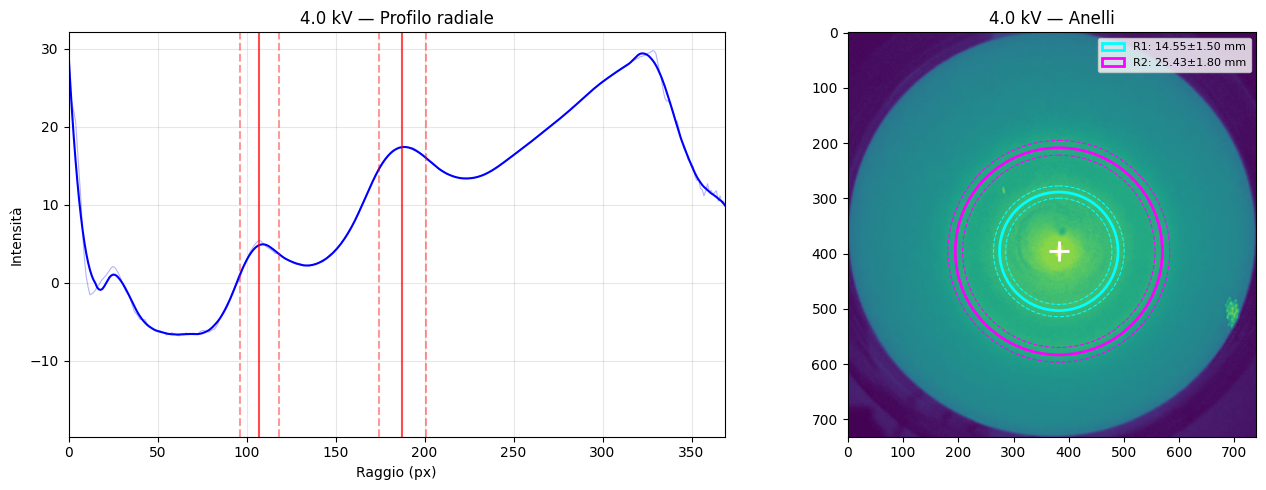


  ANALISI: 4500_c1.jpeg  —  V = 4.5 kV
  Schermo: Ø = 811.4 px = 100 mm  →  0.123249 mm/px
  Centro diffrazione: (386.8, 408.8) px
  Picchi trovati: 2
  Ring 1: r_int=94.1  r_ext=114.9  →  r = 12.881 ± 1.284 mm
  Ring 2: r_int=168.1  r_ext=194.9  →  r = 22.367 ± 1.651 mm


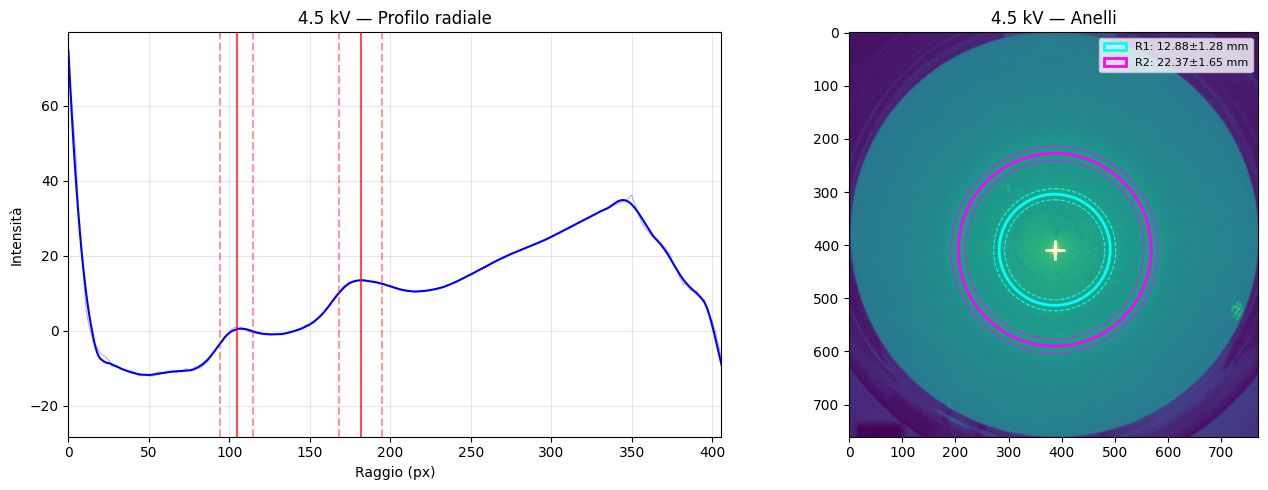


  ANALISI: 4050_c1.jpeg  —  V = 4.05 kV
  Schermo: Ø = 596.6 px = 100 mm  →  0.167628 mm/px
  Centro diffrazione: (298.5, 319.5) px
  Picchi trovati: 2
  Ring 1: r_int=76.4  r_ext=95.0  →  r = 14.362 ± 1.563 mm
  Ring 2: r_int=138.0  r_ext=161.7  →  r = 25.118 ± 1.984 mm


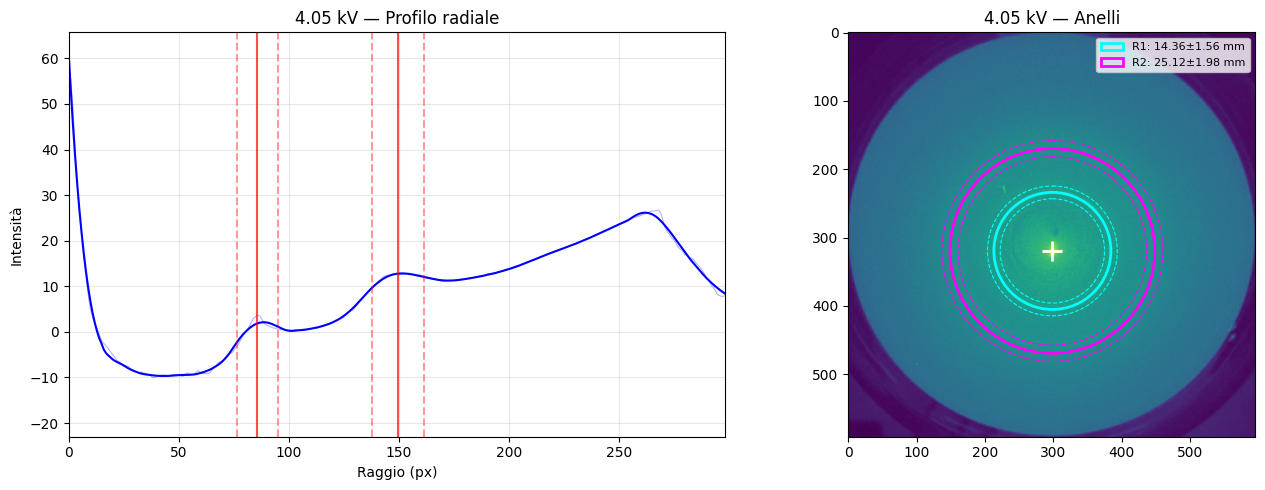


  ANALISI: 3900_c1.jpeg  —  V = 3.9 kV
  Schermo: Ø = 621.1 px = 100 mm  →  0.160992 mm/px
  Centro diffrazione: (312.1, 319.2) px
  Picchi trovati: 2
  Ring 1: r_int=78.0  r_ext=96.0  →  r = 14.010 ± 1.445 mm
  Ring 2: r_int=141.4  r_ext=164.7  →  r = 24.635 ± 1.877 mm


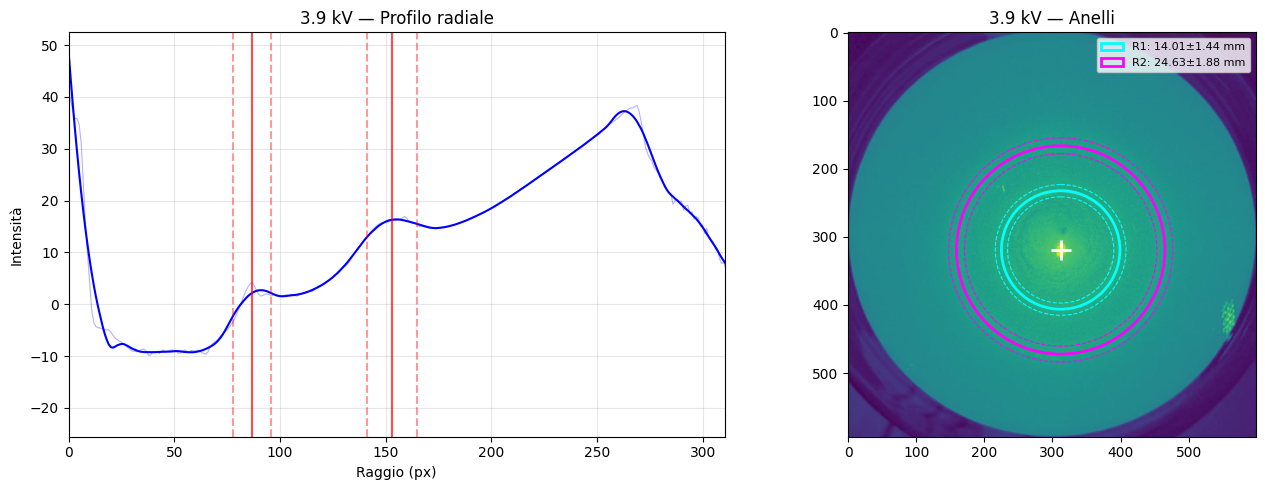


  ANALISI: 4550_c2.jpeg  —  V = 4.55 kV
  Schermo: Ø = 749.7 px = 100 mm  →  0.133380 mm/px
  Centro diffrazione: (346.8, 352.2) px
  Picchi trovati: 1
  Ring 1: r_int=146.2  r_ext=164.9  →  r = 20.748 ± 1.249 mm


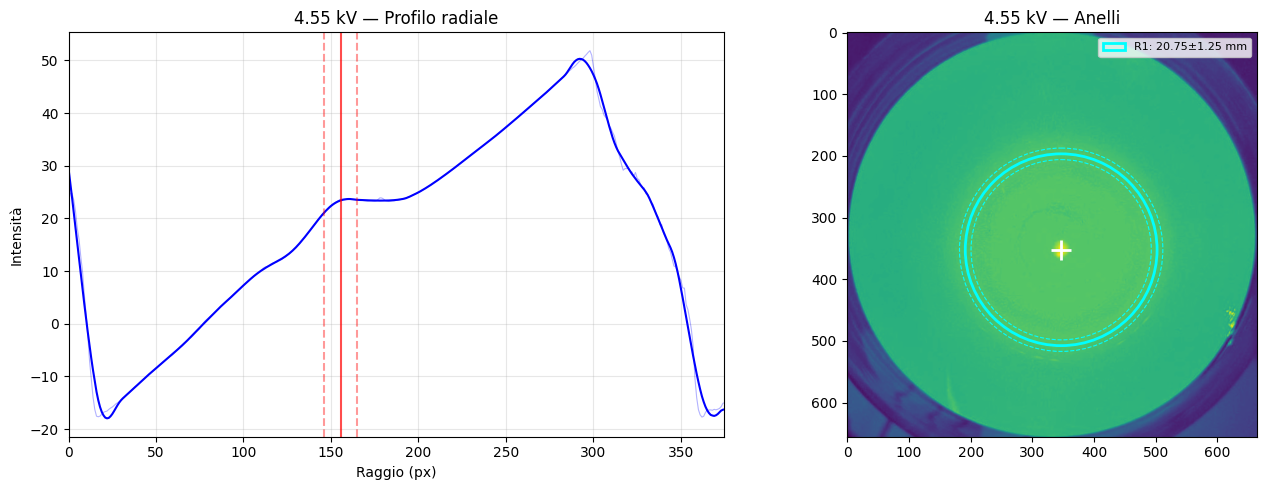


  ANALISI: 3750_c2.jpeg  —  V = 3.75 kV
  Schermo: Ø = 643.6 px = 100 mm  →  0.155375 mm/px
  Centro diffrazione: (330.4, 345.6) px
  Picchi trovati: 2
  Ring 1: r_int=87.6  r_ext=105.2  →  r = 14.979 ± 1.367 mm
  Ring 2: r_int=162.4  r_ext=181.9  →  r = 26.743 ± 1.517 mm


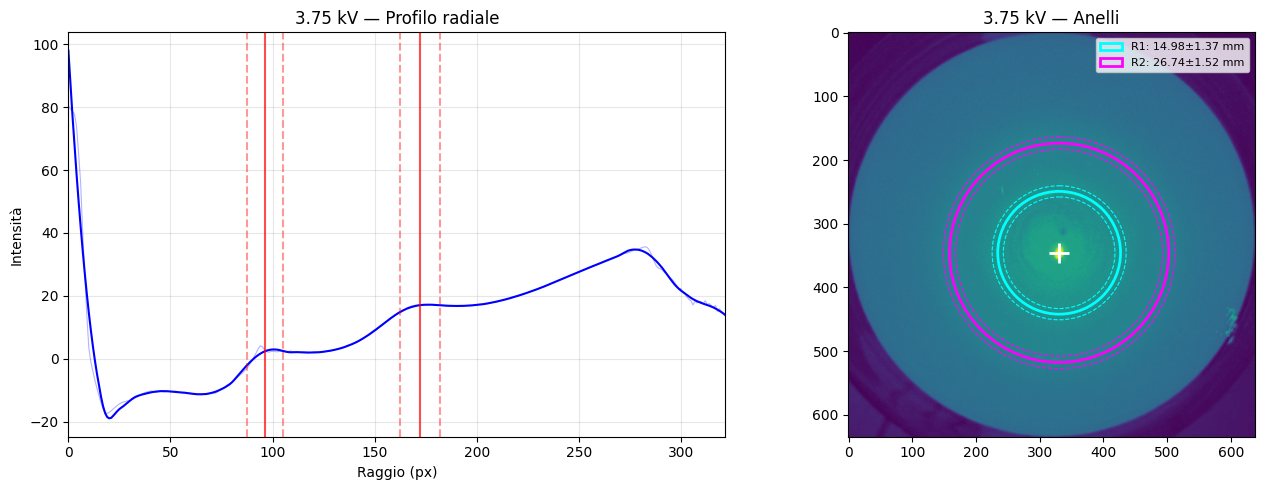


  ANALISI: 4350_c1.jpeg  —  V = 4.35 kV
  Schermo: Ø = 626.0 px = 100 mm  →  0.159745 mm/px
  Centro diffrazione: (296.8, 310.7) px
  Picchi trovati: 2
  Ring 1: r_int=70.5  r_ext=91.3  →  r = 12.923 ± 1.664 mm
  Ring 2: r_int=124.6  r_ext=147.0  →  r = 21.694 ± 1.793 mm


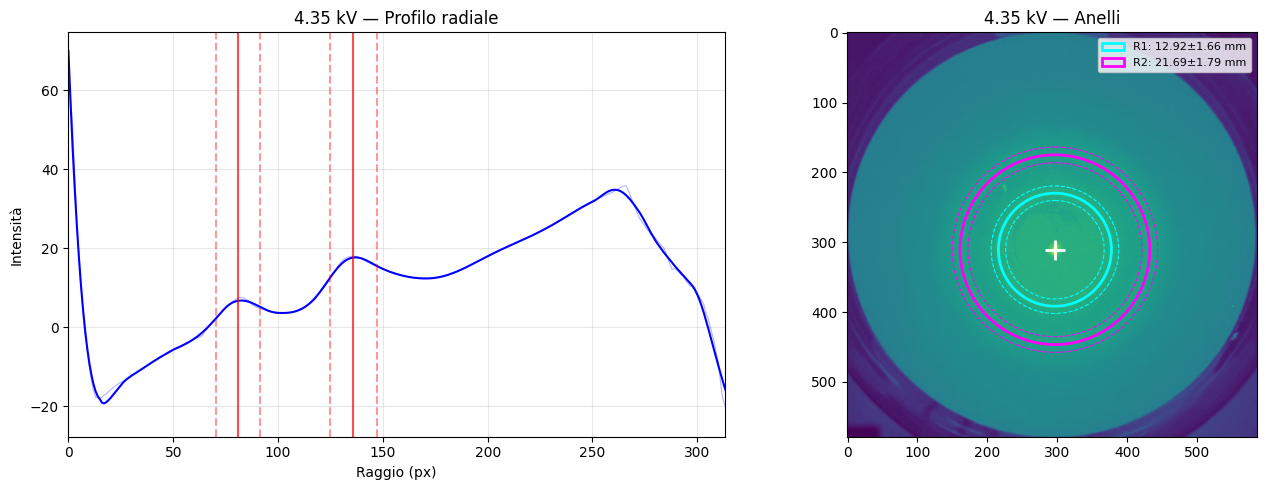


  ANALISI: 3200_c2.jpeg  —  V = 3.2 kV
  Schermo: Ø = 648.5 px = 100 mm  →  0.154200 mm/px
  Centro diffrazione: (334.9, 358.2) px
  Picchi trovati: 0


/var/folders/rl/k281mdw55z38pk7y_l5bjr1w0000gn/T/ipykernel_39281/1347720318.py:233: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right', fontsize=8)


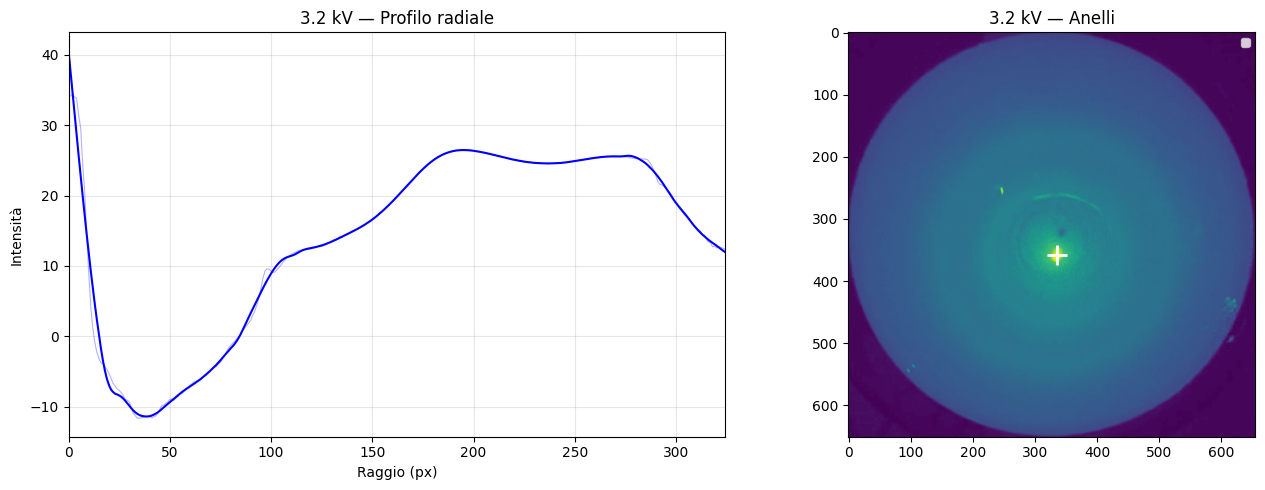


  ANALISI: 4350_v.jpeg  —  V = 4.35 kV
  Schermo: Ø = 1243.9 px = 100 mm  →  0.080391 mm/px
  Centro diffrazione: (636.1, 678.8) px
  Picchi trovati: 2
  Ring 1: r_int=170.3  r_ext=193.2  →  r = 14.611 ± 0.917 mm
  Ring 2: r_int=294.9  r_ext=321.6  →  r = 24.782 ± 1.074 mm


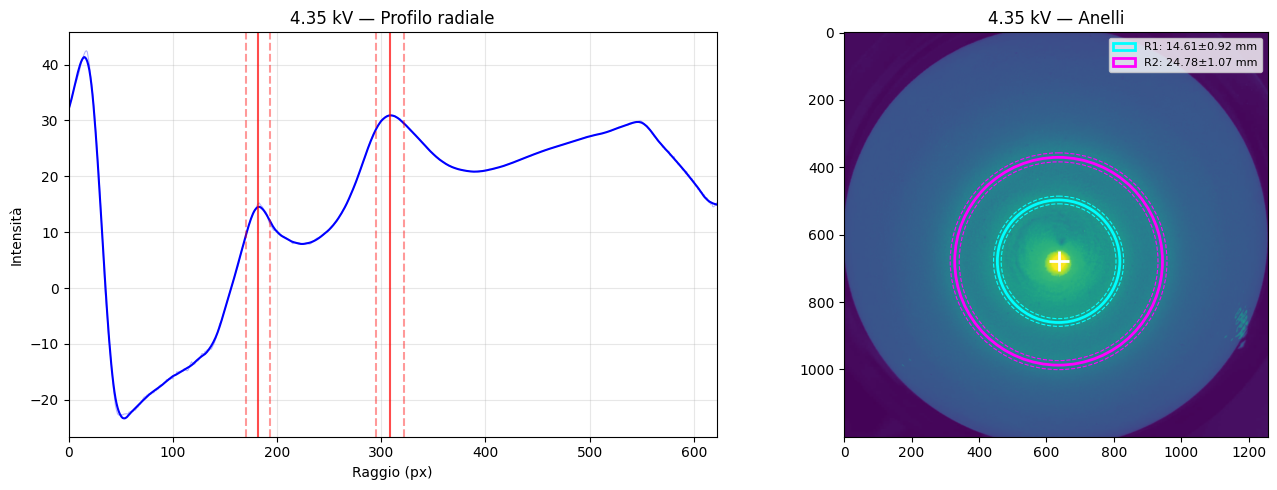


  ANALISI: 4200_c2.jpeg  —  V = 4.2 kV
  Schermo: Ø = 742.5 px = 100 mm  →  0.134678 mm/px
  Centro diffrazione: (382.4, 398.6) px
  Picchi trovati: 2
  Ring 1: r_int=95.7  r_ext=117.4  →  r = 14.349 ± 1.457 mm
  Ring 2: r_int=171.0  r_ext=196.6  →  r = 24.753 ± 1.725 mm


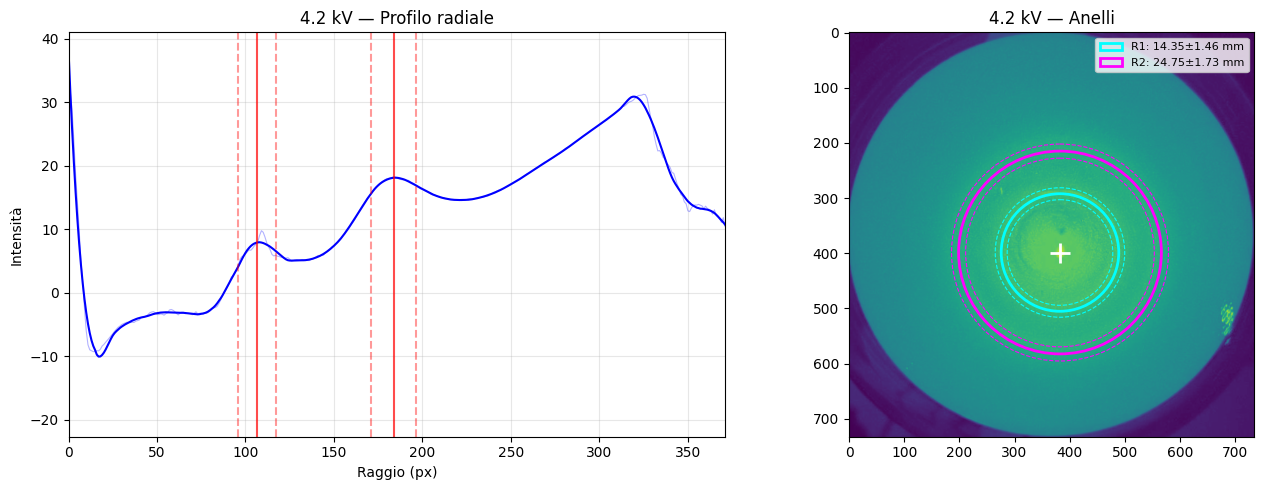


  ANALISI: 3600_c1.jpeg  —  V = 3.6 kV
  Schermo: Ø = 627.2 px = 100 mm  →  0.159448 mm/px
  Centro diffrazione: (311.6, 327.8) px
  Picchi trovati: 2
  Ring 1: r_int=81.2  r_ext=100.3  →  r = 14.469 ± 1.518 mm
  Ring 2: r_int=150.5  r_ext=173.1  →  r = 25.796 ± 1.806 mm


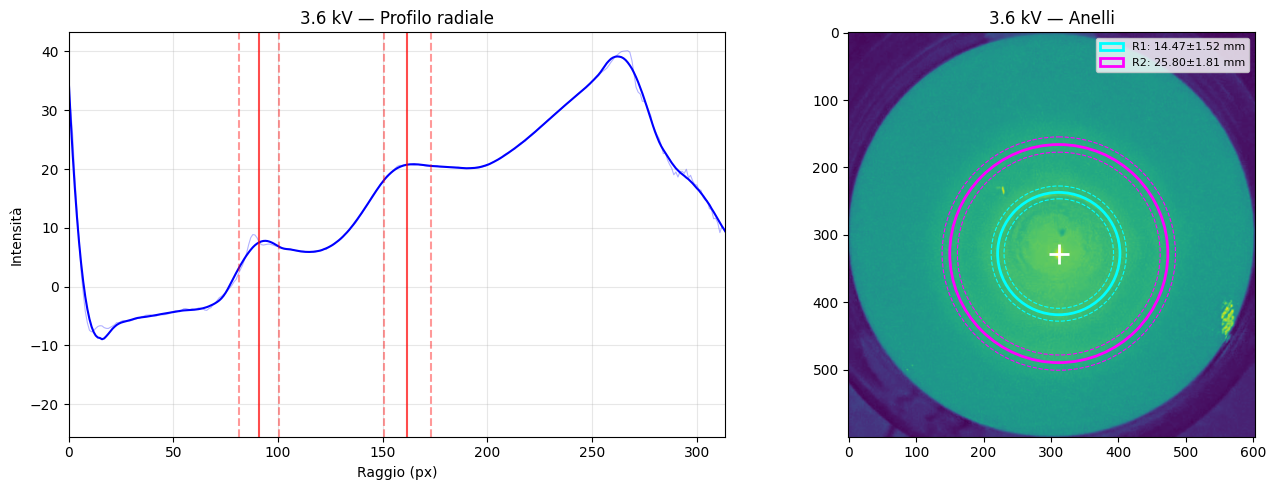


  ANALISI: 4100_v.jpeg  —  V = 4.1 kV
  Schermo: Ø = 1249.0 px = 100 mm  →  0.080064 mm/px
  Centro diffrazione: (640.6, 674.7) px
  Picchi trovati: 2
  Ring 1: r_int=170.9  r_ext=193.7  →  r = 14.595 ± 0.911 mm
  Ring 2: r_int=297.8  r_ext=324.6  →  r = 24.916 ± 1.070 mm


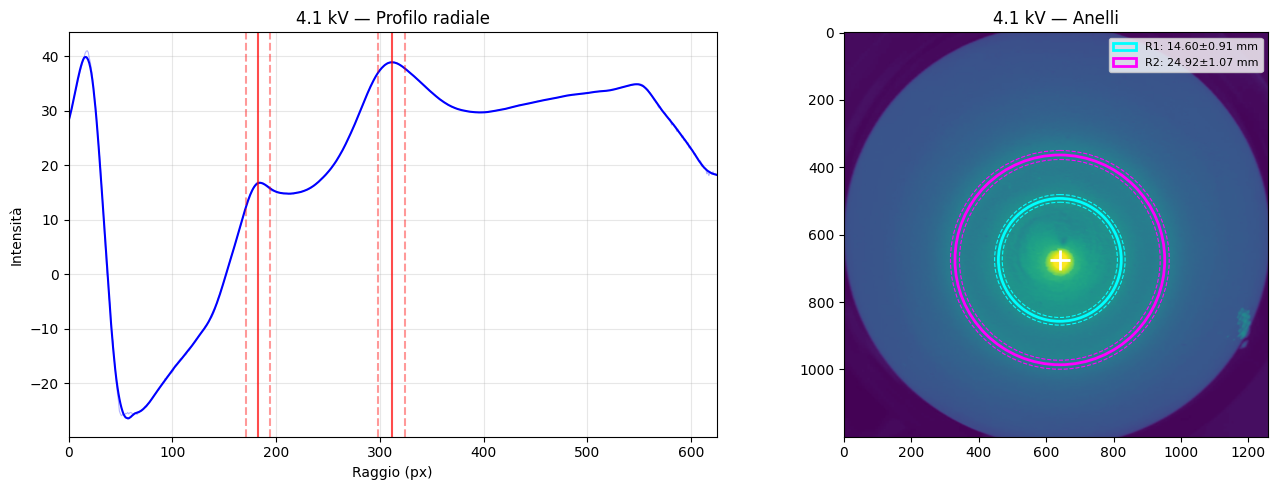


  ANALISI: 3300_c2.jpeg  —  V = 3.3 kV
  Schermo: Ø = 595.2 px = 100 mm  →  0.167997 mm/px
  Centro diffrazione: (296.7, 327.8) px
  Picchi trovati: 0


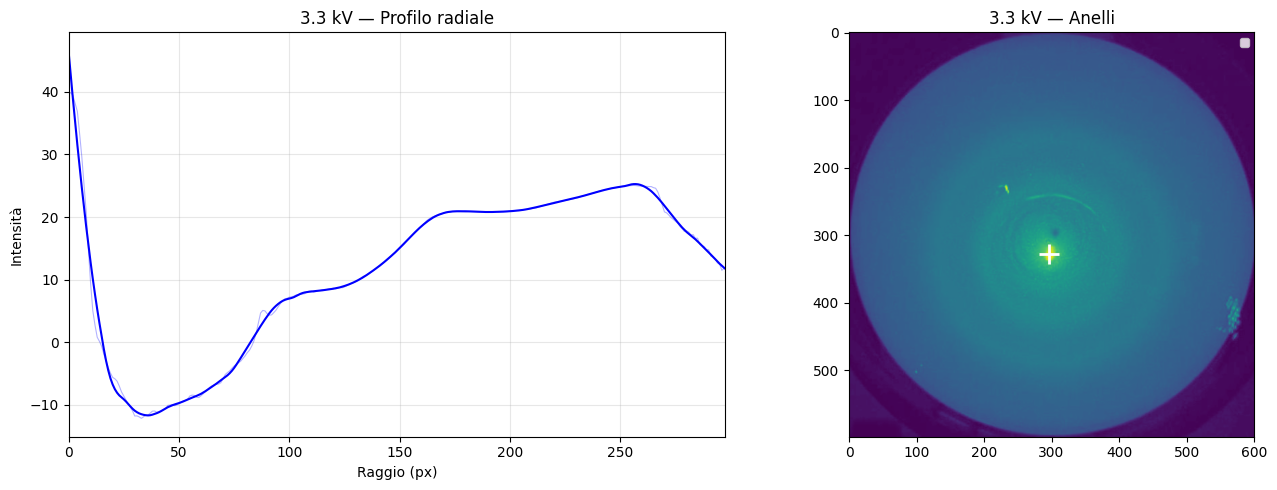

In [78]:
risultati=[]
for nome in immagini:
    temp=analyze_image(nome, immagini[nome], float(nome[0:4])/1000)
    risultati.append(temp)

In [79]:
risultati

[{'voltage_kV': 3.6,
  'mm_per_px': np.float64(0.15772303491258294),
  'rings': [{'ring': 1,
    'r_inner_px': np.float64(84.34140302240927),
    'r_outer_px': np.float64(106.29794202902342),
    'r_medio_px': np.float64(95.31967252571634),
    'delta_r_px': np.float64(10.978269503307075),
    'r_inner_mm': np.float64(13.302582053479686),
    'r_outer_mm': np.float64(16.765634021779377),
    'r_medio_mm': np.float64(15.034108037629531),
    'delta_r_mm': np.float64(1.7315259841498463)},
   {'ring': 2,
    'r_inner_px': np.float64(156.08905298435775),
    'r_outer_px': np.float64(180.88345679239004),
    'r_medio_px': np.float64(168.48625488837388),
    'delta_r_px': np.float64(12.397201904016143),
    'r_inner_mm': np.float64(24.618839153323865),
    'r_outer_mm': np.float64(28.52948777077482),
    'r_medio_mm': np.float64(26.57416346204934),
    'delta_r_mm': np.float64(1.9553243087254777)}]},
 {'voltage_kV': 2.9,
  'mm_per_px': np.float64(0.14482365686651943),
  'rings': [{'ring': 1,

In [80]:
voltaggi_r10=[]
raggi_10=[]
errori_r10=[]

voltaggi_r11=[]
raggi_11=[]
errori_r11=[]

for i in range(0,18):
    r10=risultati[i]['rings'][0]['r_medio_mm']
    v10=risultati[i]['voltage_kV']
    err10=risultati[i]['rings'][0]['delta_r_mm']
    r11=risultati[i]['rings'][1]['r_medio_mm']
    v11=risultati[i]['voltage_kV']
    err11=risultati[i]['rings'][1]['delta_r_mm']
    voltaggi_r10.append(v10)
    raggi_10.append(r10)
    errori_r10.append(err10)
    voltaggi_r11.append(v11)
    raggi_11.append(r11)
    errori_r11.append(err11)

IndexError: list index out of range

In [ ]:
voltaggi_r10

[3.6,
 2.9,
 4.5,
 3.8,
 3.4,
 4.0,
 4.5,
 4.05,
 3.9,
 4.55,
 3.75,
 4.35,
 3.2,
 4.35,
 4.2,
 3.6,
 4.1,
 3.3]

<ErrorbarContainer object of 3 artists>

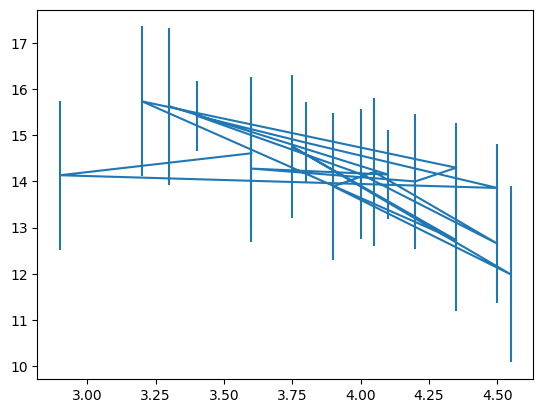

In [ ]:
plt.errorbar(x=voltaggi_r10, y=raggi_10, yerr=errori_r10 )  

<ErrorbarContainer object of 3 artists>

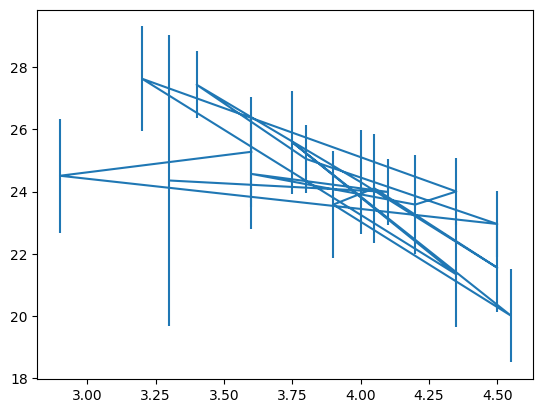

In [ ]:
plt.errorbar(x=voltaggi_r11, y=raggi_11, yerr=errori_r11 )

In [ ]:
list(immagini.keys())

['3600_c2.jpeg',
 '2900_c2.jpeg',
 '4500_v.jpeg',
 '3800_v.jpeg',
 '3400_v.jpeg',
 '4000_c2.jpeg',
 '4500_c1.jpeg',
 '4050_c1.jpeg',
 '3900_c1.jpeg',
 '4550_c2.jpeg',
 '3750_c2.jpeg',
 '4350_c1.jpeg',
 '3200_c2.jpeg',
 '4350_v.jpeg',
 '4200_c2.jpeg',
 '3600_c1.jpeg',
 '4100_v.jpeg',
 '3300_c2.jpeg']

In [ ]:
raggi_10

[np.float64(14.608209450585669),
 np.float64(14.132897524374563),
 np.float64(13.85762304078559),
 np.float64(14.83762168230661),
 np.float64(15.42120700204135),
 np.float64(14.159840771141681),
 np.float64(12.652912148520956),
 np.float64(14.202986215545831),
 np.float64(13.893231961213825),
 np.float64(11.984621134603143),
 np.float64(14.752239984701346),
 np.float64(12.728521659037307),
 np.float64(15.732162547740923),
 np.float64(14.295788703025936),
 np.float64(13.99859240067851),
 np.float64(14.276839465305024),
 np.float64(14.147758163124232),
 np.float64(15.625893748029908)]

In [ ]:
errori_r10

[np.float64(1.6542206184457517),
 np.float64(1.613214010691914),
 np.float64(0.9605384200001159),
 np.float64(0.8755488660626501),
 np.float64(0.7579092340188318),
 np.float64(1.4168863893253865),
 np.float64(1.2770471819939953),
 np.float64(1.5927004496706487),
 np.float64(1.5845935583511077),
 np.float64(1.9048862076527326),
 np.float64(1.554489663977193),
 np.float64(1.523830024650808),
 np.float64(1.6209728086141393),
 np.float64(0.9574339640712741),
 np.float64(1.4551827892046056),
 np.float64(1.5944380727905147),
 np.float64(0.9672691744191745),
 np.float64(1.6937381733540895)]

In [ ]:
raggi_11

[np.float64(25.280442414886835),
 np.float64(24.510939737642396),
 np.float64(22.96141971104362),
 np.float64(25.05167344324188),
 np.float64(27.434546940849337),
 np.float64(24.30767422386926),
 np.float64(21.55767921955867),
 np.float64(24.109663560267112),
 np.float64(23.584644319459503),
 np.float64(20.017822438317307),
 np.float64(25.58655165552297),
 np.float64(21.34429856089264),
 np.float64(27.62763421583444),
 np.float64(24.00584404744609),
 np.float64(23.585214490292323),
 np.float64(24.570261486439872),
 np.float64(23.991469043145816),
 np.float64(24.35821551715315)]

In [ ]:
errori_r11

[np.float64(1.772285207350602),
 np.float64(1.8223832780642226),
 np.float64(1.0503465778014256),
 np.float64(1.0879541548497556),
 np.float64(1.0732065597335652),
 np.float64(1.6731746699631491),
 np.float64(1.4151791181837192),
 np.float64(1.7477286396192635),
 np.float64(1.7056280294042696),
 np.float64(1.503501981343849),
 np.float64(1.6557699404670525),
 np.float64(1.67594994315857),
 np.float64(1.6773502082984084),
 np.float64(1.0609821789779856),
 np.float64(1.5773710744623908),
 np.float64(1.778971397062803),
 np.float64(1.0661672525943038),
 np.float64(4.669199814062034)]